In [2]:
import pandas as pd
from Functions import *
from Telescope import *

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.lines import Line2D
import seaborn as sns
from matplotlib import colors

from matplotlib.animation import FuncAnimation

from scipy.optimize import curve_fit

import itertools

In [3]:
savedir = "/Users/ben_coull-neveu/Dropbox/- School -/Ariel Summer Internship 2024/target diversity paper plots/"

In [4]:
# set resolution to 180 dpi
plt.rcParams['figure.dpi'] = 180

## Define leverage to be:
$$\text{Leverage} = \sqrt{N}\cdot \text{Stddev}(N)$$

In [5]:
def leverage (df, col):
    return np.sqrt(df.shape[0]) * df[col].std()

def linfunc(x, a, b):
    return a*x + b

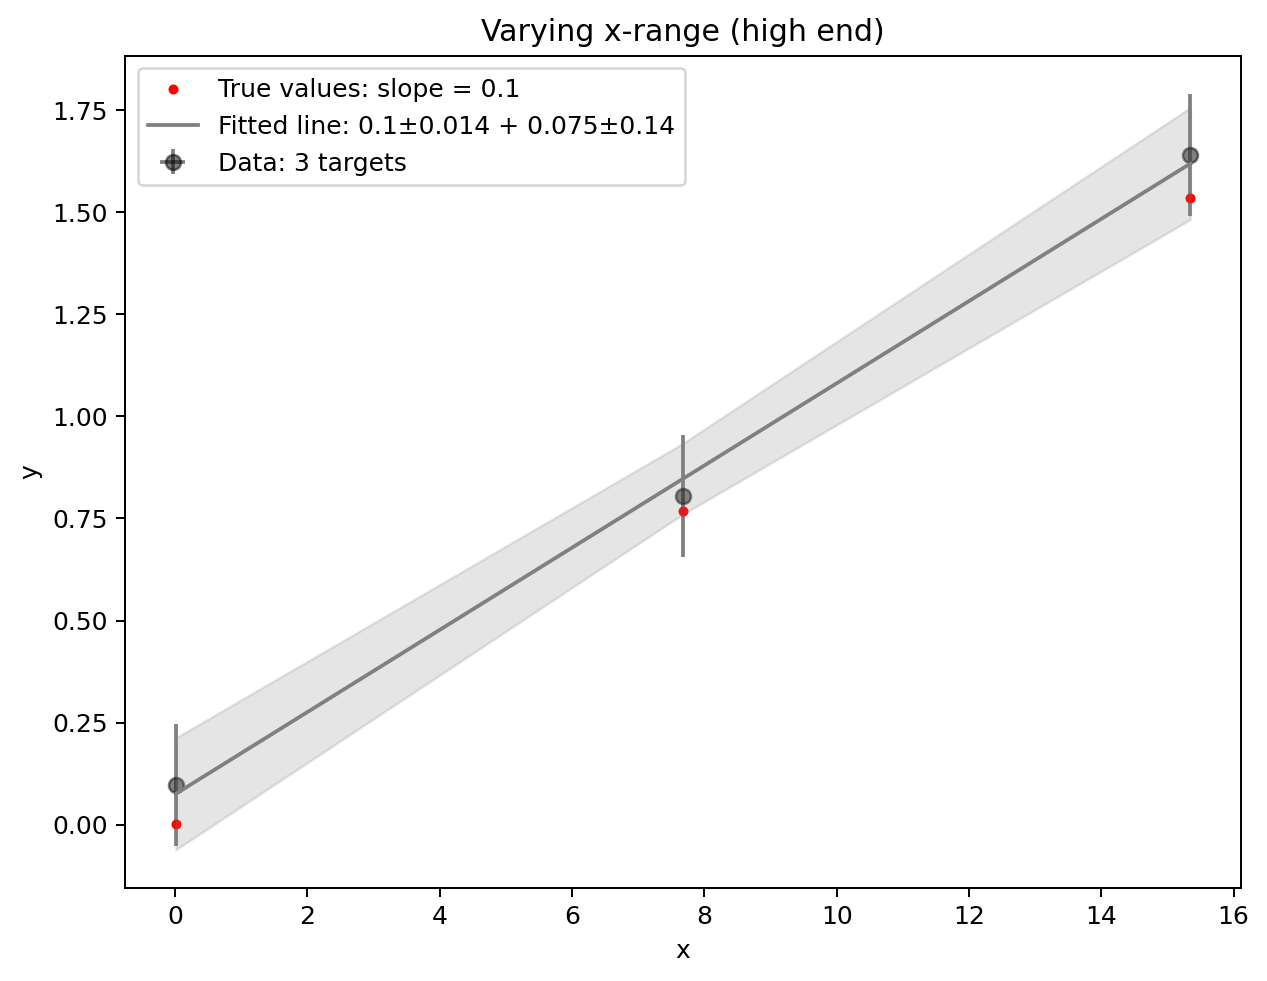

In [6]:
Nmax = 400
Nmax += 1 # to include Nmax in the range

b = 0 # y-intercept


levs = []
uncs = []
Ns = []
xs = []
slopes = []
stds = []

## uncomment for varying number of targets
# xmax = 1
# s = 0.1
# N = np.arange(3, Nmax) # number of targets
# for Ni in N:

# uncomment for varying x range
# Ni = 100
# s = 0.1
# xmaxs = np.linspace(0.2, 5, 100)
# for xmax in xmaxs:
    
# uncomment for varying slope
# Ni = 100
# xmax = 1
# slope = np.linspace(0.1,100, 1000)
# for s in slope:

# uncomment for varying x range AND number of targets
s = 0.1
N = np.arange(3, Nmax) # number of targets
xmaxs = np.linspace(0.2, 20, Nmax)
# randomly reorder the xmaxs
N = np.flip(N)
np.random.shuffle(xmaxs)
for Ni, xmax in zip(N, xmaxs):

# uncomment for varying x range AND number of targets into meshgrid. Must indent code below as well
# s = 0.1
# N = np.arange(3, Nmax) # number of targets
# xmaxs = np.linspace(0.2, 5, Nmax)
# for Ni in N: 
#     for xmax in xmaxs:

        
    # generate x data between a and b, where a and b are some values
    # x = np.random.uniform(0.1, xmax, Ni) # x-axis values
    x = np.linspace(0.01, xmax, Ni) # x-axis values
    # x = np.random.random(Ni) # x-axis values
    # x = np.random.normal(0.5, 0.15, Ni) # x-axis values
    y = s*x + b

    df = pd.DataFrame()
    df["x0"] = x
    df["y0"] = y

    df["x_unc"] = 0 # keeping x uncertainty 0
    df["y_unc"] = 0.15 # keeping y uncertainty constant. Chose absolute value of 0.15
    # df["y_unc"] = df["y0"]/7 # SNR of 7
    # df["y_unc"] = abs(np.random.normal(0.15, 0.1, Ni)) # adding noise to y

    df["x"] = np.random.normal(df['x0'], df["x_unc"], Ni) # adding noise to x
    df["y"] = np.random.normal(df['y0'], df["y_unc"], Ni) # adding noise to y
    
    # df['x'] = df['x0'] + df['x_unc']
    # df['y'] = df['y0'] + df['y_unc']
    
    popt, pcov = curve_fit(linfunc, df['x'], df['y'], sigma=df["y_unc"], absolute_sigma=True, p0=[s, b])
    both_unc = np.sqrt(np.diag(pcov)) # standard deviation of the slope
    unc = both_unc[0] # slope uncertainty
    # unc = abs(unc / popt[0]) # relative error of the slope
    uncs.append(unc) # append slope uncertainty to list

    lev = leverage(df, "x")
    levs.append(lev)
    
    Ns.append(Ni)
    xs.append(xmax)
    slopes.append(s)
    stds.append(df["x"].std())

fig, ax = plt.subplots(figsize=(8, 6))

df.sort_values("x", inplace=True)
ax.errorbar(df["x"], df["y"], xerr=df["x_unc"], yerr=df["y_unc"], fmt='o', color='black', alpha=0.5, label=f"Data: {df.shape[0]} targets", zorder=10)
ax.plot(df["x0"], df["y0"], '.', color='red', label=f"True values: slope = {s:.2}", zorder=15)

ax.plot(df["x"], linfunc(df["x"], *popt), 'gray', label=f"Fitted line: {popt[0]:.2}\u00b1{both_unc[0]:.2} + {popt[1]:.2}\u00b1{both_unc[1]:.2}", zorder=20)
# Given: popt = [m, c] and covariance matrix pcov
var_m = pcov[0, 0]
var_c = pcov[1, 1]
cov_mc = pcov[0, 1]
# Compute the uncertainty in the prediction at each x:
pred_unc = np.sqrt(var_m * x**2 + var_c + 2 * cov_mc * x)
ax.fill_between(df["x"], linfunc(df["x"], *popt) - pred_unc, linfunc(df["x"], *popt) + pred_unc, color='gray', alpha=0.2, zorder=20)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Varying x-range (high end)")
ax.legend()
# ax.set_xlim(0, 1)
plt.show()

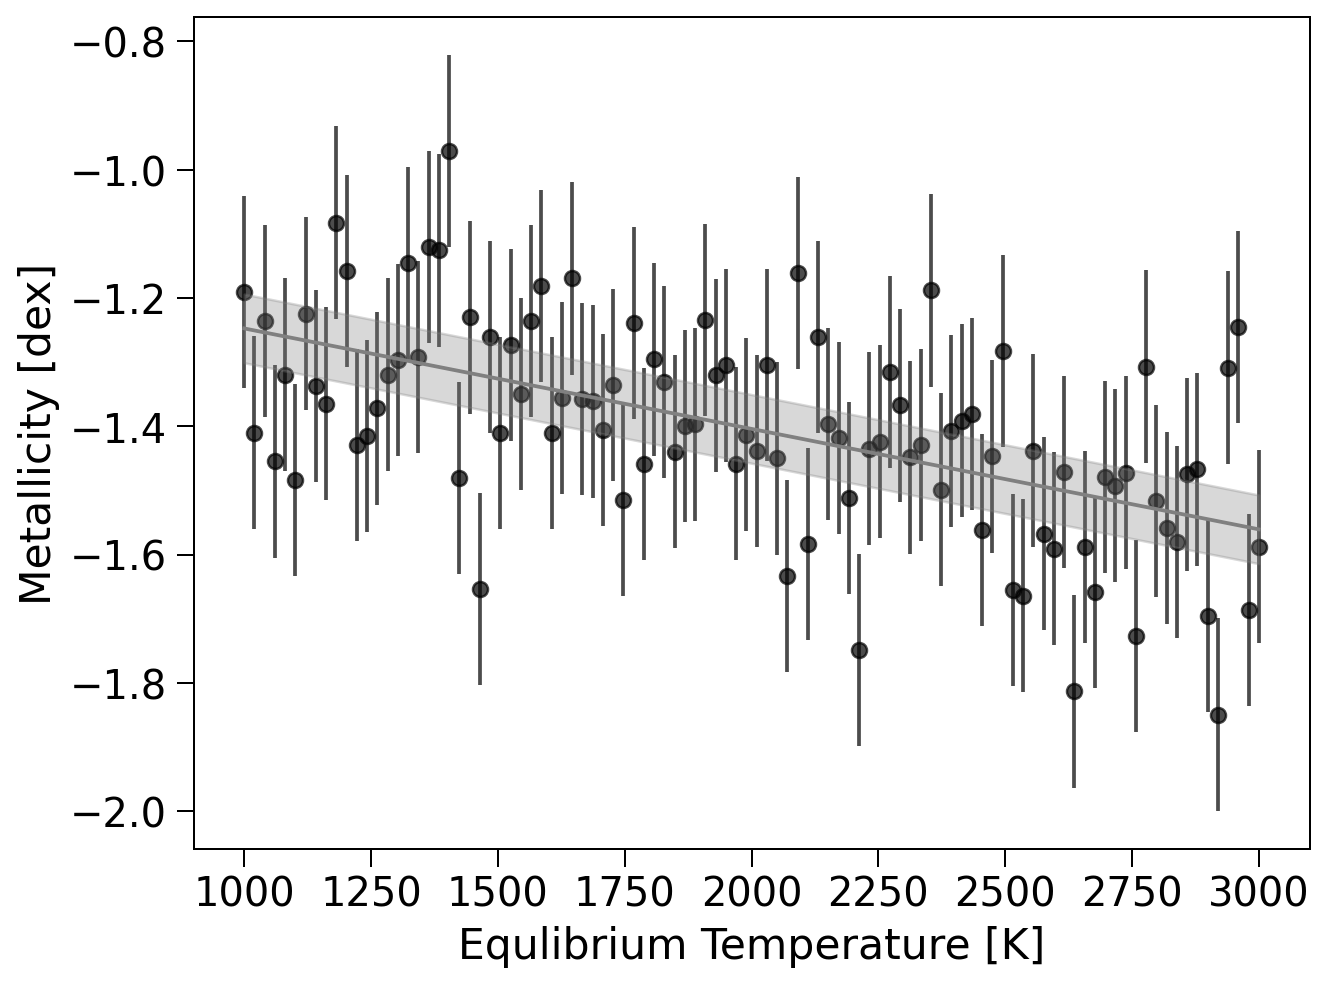

In [23]:
s, b = -0.0002, -1

Ni = 100

x0, x1 = 1000, 3000
x = np.linspace(x0, x1, Ni) # x-axis values
y = s*x + b

df = pd.DataFrame()
df["x0"] = x
df["y0"] = y

df["x_unc"] = 0 # keeping x uncertainty 0
df["y_unc"] = 0.15 # keeping y uncertainty constant. Chose absolute value of 0.15

df["x"] = np.random.normal(df['x0'], df["x_unc"], Ni) # adding noise to x
df["y"] = np.random.normal(df['y0'], df["y_unc"], Ni) # adding noise to y


fig, ax = plt.subplots(figsize=(8, 6))

fontsize=17

df.sort_values("x", inplace=True)
ax.errorbar(df["x"], df["y"], yerr=df["y_unc"], fmt='o', color='black', alpha=0.7, zorder=1)

popt, pcov = curve_fit(linfunc, df['x'], df['y'], sigma=df["y_unc"], absolute_sigma=True, p0=[s, b])
var_m = pcov[0, 0]
var_c = pcov[1, 1]
cov_mc = pcov[0, 1]
# Compute the uncertainty in the prediction at each x:
pred_unc = np.sqrt(var_m * np.log10(x)**2 + var_c + 2 * cov_mc * np.log10(x))
ax.plot(df["x"], linfunc(df["x"], *popt), 'gray', zorder=20)
ax.fill_between(df["x"], linfunc(df["x"], *popt) - pred_unc, linfunc(df["x"], *popt) + pred_unc, color='gray', alpha=0.3, zorder=25)

# ax.set_xscale('log')

ax.set_xlabel("Equlibrium Temperature [K]", fontsize=fontsize)
ax.set_ylabel("Metallicity [dex]", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize-1, size=7)  
ax.tick_params(axis='both', which='minor', labelsize=fontsize-1, size=3)

plt.savefig(savedir + "Simulated Metllicity vs Teq.png", dpi=300, bbox_inches='tight')

plt.show()

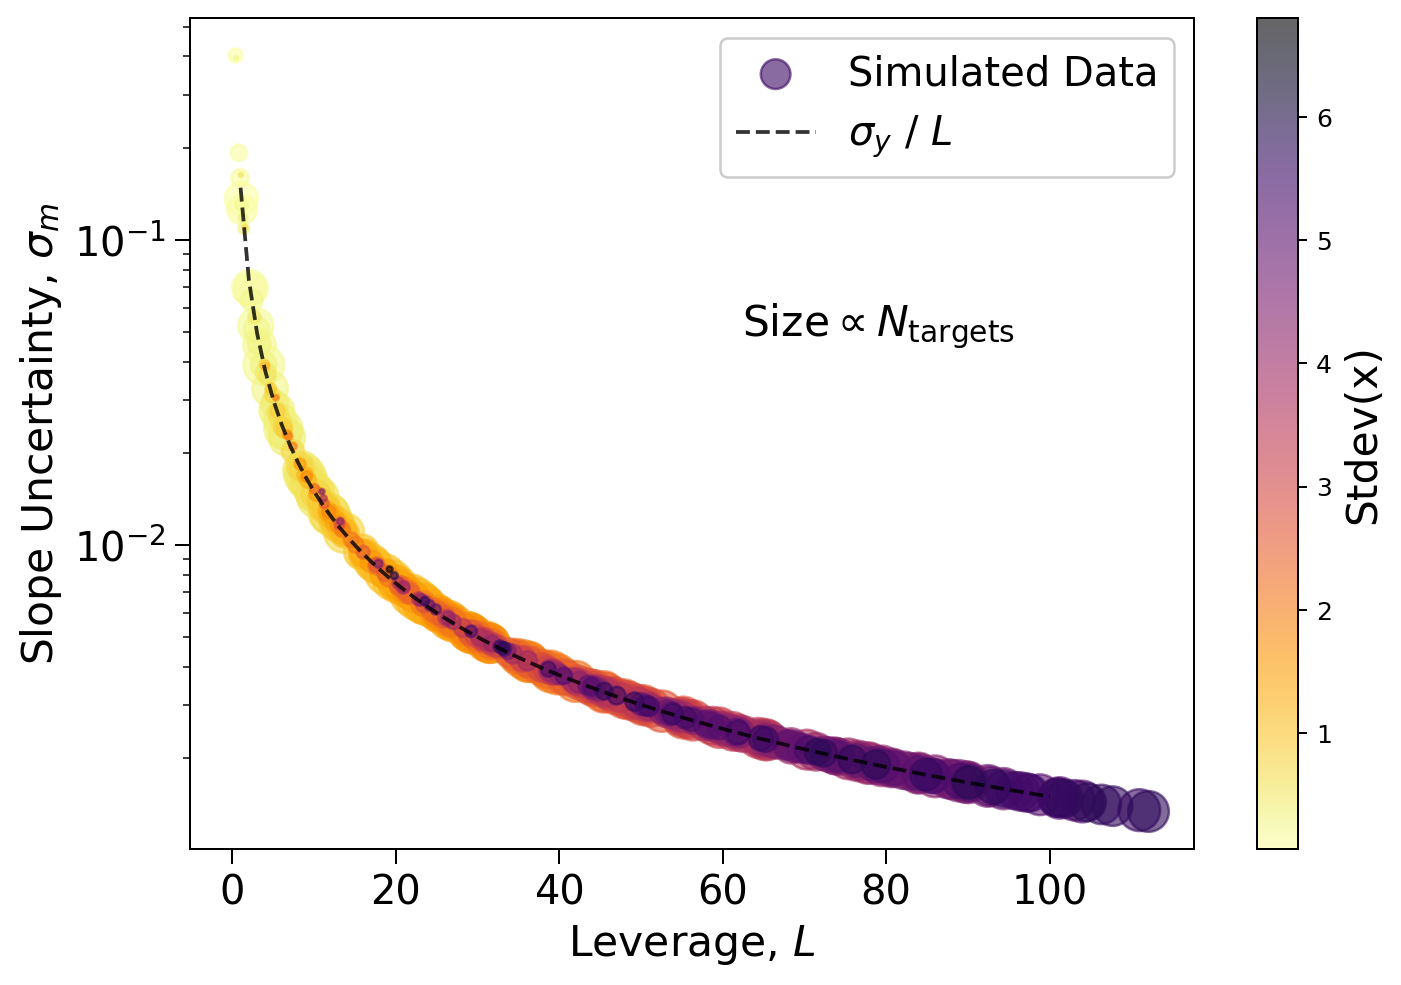

In [8]:
# plt.scatter(levs, uncs, label="Leverage", c=Ns, cmap='inferno', alpha=0.7)
# plt.scatter(levs, uncs, label="Leverage", c=xs, cmap='inferno', alpha=0.7)
# plt.scatter(slopes, uncs, label="Leverage", cmap='inferno', alpha=0.7)

fig, ax = plt.subplots(figsize=(9, 6))



plt.scatter(levs, uncs, label="Simulated Data", s=np.array(Ns)*0.7, c=stds, marker='o', cmap='inferno_r', alpha=0.6)
ax.text(0.55, 0.6, r"Size$\propto N_\text{targets}$", fontsize=fontsize, color='black', ha='left', va='bottom', transform=ax.transAxes) # place text at absolute coordinates

# plt.colorbar(label="Number of Targets")
# plt.colorbar(label="max x-value")
plt.colorbar().set_label("Stdev(x)", size=fontsize)

# plt.colorbar(label="Slope")
# plt.xlabel("Slope")

xdata = np.linspace(0, 100, 100)
ydata = 0.15 / xdata
ax.plot(xdata, ydata, 'k--', label=r"$\sigma_y\ /\ L$", alpha=0.8)

# plt.colorbar(label="Number of Targets")
ax.set_ylabel(r"Slope Uncertainty, $\sigma_m$", fontsize=fontsize)
ax.set_xlabel(r"Leverage, $L$", fontsize=fontsize)
# plt.title("Slope Uncertainty vs Leverage", fontsize=14)

ax.set_yscale('log')

ax.legend(fontsize=fontsize-1, loc='upper right', framealpha=1)
ax.tick_params(axis='both', which='major', labelsize=fontsize-1, size=6)
ax.tick_params(axis='both', which='minor', labelsize=fontsize-1, size=3)

plt.savefig(savedir + "Slope Uncertainty vs Leverage.png", dpi=300, bbox_inches='tight')

plt.show() 

In [9]:
# your fixed slope
s = 0.1

Nmax = 500
xmax_count = 100

# the two parameter ranges
N = np.arange(3, Nmax) # number of targets
xmax_vals = np.linspace(0.2, 5, xmax_count)     # upper x‐limit

# build the meshgrid (shape: (len(N), len(xmax_vals)))
Ni_grid, xmax_grid = np.meshgrid(N, xmax_vals, indexing="ij")

# flatten both grids to get a list of (Ni, xmax) pairs
Ni_flat   = Ni_grid .ravel()
xmax_flat = xmax_grid.ravel()

# prepare result containers
uncs, levs, Ns, xs, slopes = [], [], [], [], []

for Ni, xmax in zip(Ni_flat, xmax_flat):
    avg_unc, avg_lev = [], []
    for i in range(1):
        # Ni might be float from meshgrid; cast to int if needed
        Ni = int(Ni)

        # generate your “true” x and y
        x = np.linspace(0.01, xmax, Ni)
        y0 = s * x

        # build DataFrame with uncertainties
        df = pd.DataFrame({
            "x0":     x,
            "y0":     y0,
            "x_unc":  0.0,
            "y_unc":  0.15,
        })
        df["x"] = np.random.normal(df["x0"], df["x_unc"], Ni)
        df["y"] = np.random.normal(df["y0"], df["y_unc"], Ni)

        # fit and compute your relative slope error
        popt, pcov = curve_fit(linfunc,
                            df["x"], df["y"],
                            sigma=df["y_unc"],
                            absolute_sigma=True,
                            p0=[s, 0])
        unc = np.sqrt(np.diag(pcov))[0]
        # unc_rel  = abs(unc / popt[0])
        avg_unc.append(unc)
        avg_lev.append(leverage(df, "x"))

    # compute leverage, store everything
    lev = leverage(df, "x")

    uncs.append(np.median(avg_unc))
    levs.append(np.median(avg_lev))
    Ns.append(Ni)
    xs.append(xmax)
    slopes.append(s)

KeyboardInterrupt: 

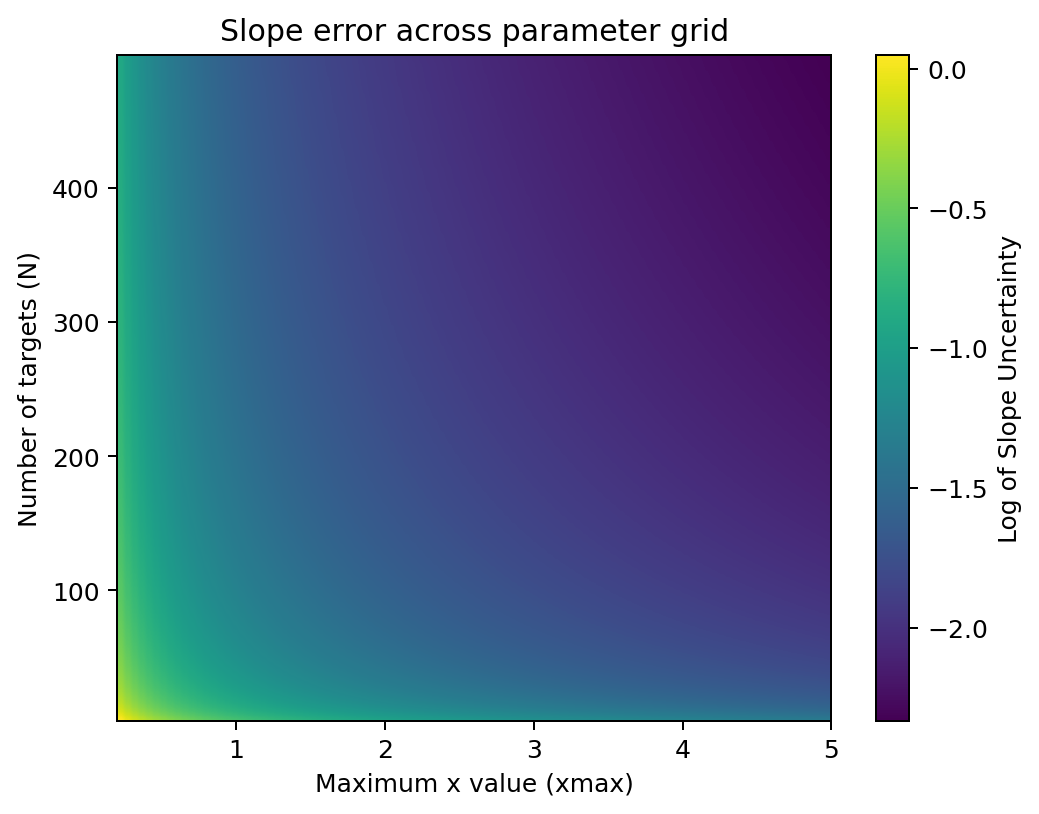

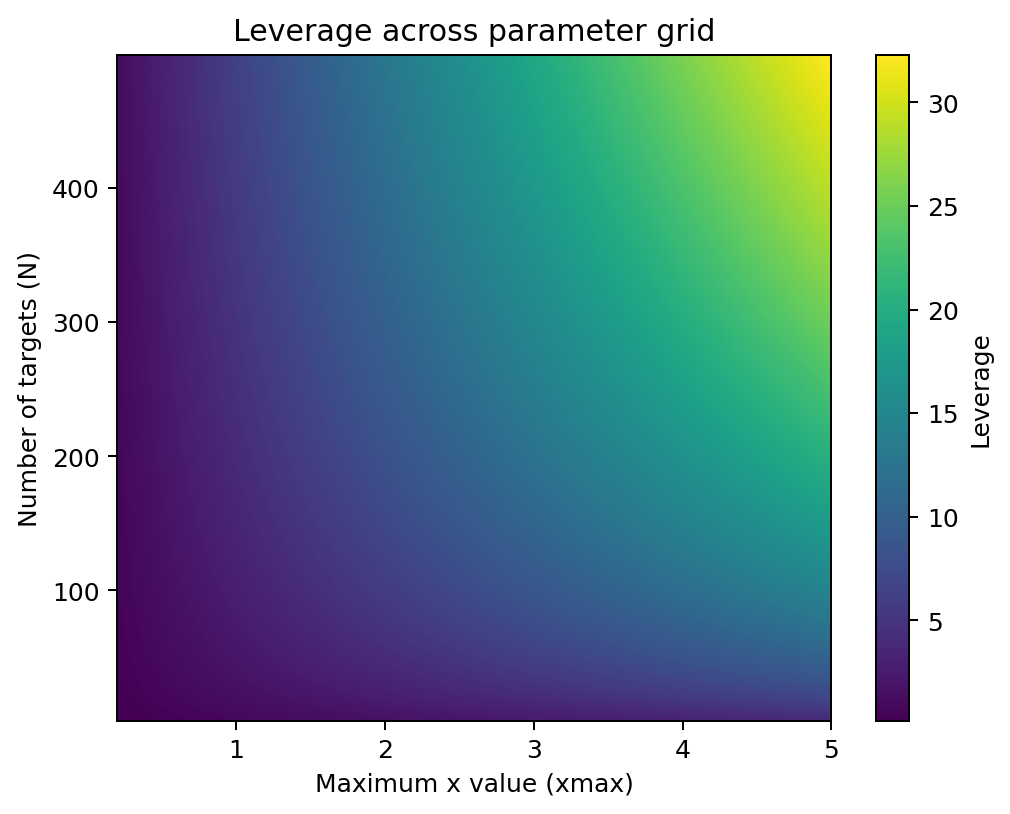

In [ ]:
# Reconstruct the unique parameter axes
N_vals = np.array(sorted(set(N)))
xmax_vals = np.array(sorted(set(xs)))

# Reshape the uncertainties into a 2D matrix
unc_matrix = np.array(uncs).reshape(len(N_vals), len(xmax_vals))

unc_matrix_log = np.log10(abs(unc_matrix))
unc_matrix_log = np.flip(unc_matrix_log, axis=0) # flip the y-axis

# Plot heatmap of slope uncertainty
plt.figure()
plt.imshow(
    unc_matrix_log,
    aspect='auto',
    extent=[xmax_vals[0], xmax_vals[-1], N_vals[0], N_vals[-1]]
)
plt.colorbar(label='Log of Slope Uncertainty')
plt.xlabel('Maximum x value (xmax)')
plt.ylabel('Number of targets (N)')
plt.title('Slope error across parameter grid')
plt.show()


# Reshape the leverage into a 2D matrix
lev_matrix = np.array(levs).reshape(len(N_vals), len(xmax_vals))
lev_matrix = np.flip(lev_matrix, axis=0) # flip the y-axis

# Plot heatmap of relative slope uncertainty
plt.figure()
plt.imshow(
    lev_matrix,
    aspect='auto',
    extent=[xmax_vals[0], xmax_vals[-1], N_vals[0], N_vals[-1]]
)
plt.colorbar(label='Leverage')
plt.xlabel('Maximum x value (xmax)')
plt.ylabel('Number of targets (N)')
plt.title('Leverage across parameter grid')
plt.show()

In [ ]:
# Overcomplicating things. See above for a simpler version

def choose_unc(df, x_unc:tuple, y_unc:tuple):
    """
    Choose the uncertainty for the x and y values.
    
    example: x_unc = (0), y_unc = (0.15) 
    >> produces a constant uncertainty for both x and y
    
    example: x_unc = (0), y_unc = (0.15, 0.1) 
    >> produces a constant uncertainty for x, but a random uncertainty for y from a gaussian distribution with mean 0.15 and std 0.1.
    """
    # if x_unc is a tuple of length 1 or is a float, use it as a constant
    if isinstance(x_unc, tuple) and len(x_unc) == 1:
        x_unc = x_unc[0]
    elif isinstance(x_unc, tuple) and len(x_unc) == 2:
        x_unc = abs(np.random.normal(x_unc[0], x_unc[1], df.shape[0]))
        
    if isinstance(y_unc, tuple) and len(y_unc) == 1:
        y_unc = y_unc[0]
    elif isinstance(y_unc, tuple) and len(y_unc) == 2:
        y_unc = abs(np.random.normal(y_unc[0], y_unc[1], df.shape[0]))

    df["x_unc"] = x_unc
    df["y_unc"] = y_unc
    
    
def sim_leverage(N, x_dict=None, y_dict=None):
    """
    Simulate the leverage of a dataset with a given number of points and slope.
    
    Parameters
    ----------
    x_dict : dict
        Dictionary with the x-axis values and their uncertainties. Can also check if clusetering is needed, and if so how the cluster is distributed.
    y_dict : dict
        Dictionary with the y-axis values and their uncertainties. Can also check if clusetering is needed, and if so how the cluster is distributed.
    """
    df = pd.DataFrame()
    
    # generate data
    df["x0"] = np.random.random(N) # x-axis values
    df["y0"] = 2*df["x0"] # set b=0 for simplicity

    # Add uncertainty to the x and y values
    choose_unc(df, 0, 0.15) # keeping y uncertainty constant. Chose absolute value of 0.15 for y and 0 for x

    # varying the x and y values
    df["x"] = np.random.normal(df['x0'], df["x_unc"], 10)
    df["y"] = np.random.normal(df['y0'], df["y_unc"], 10)

    # Calculate the leverage
    lev = leverage(df, "y")
    
    return lev

[2.471067139844897,
 4.605172449350442,
 inf,
 2.883515424102021,
 inf,
 0.13683937130503088,
 0.9539332403929484,
 0.5326956786107095,
 0.2058789766357763,
 0.025701023942446236,
 0.7097996852956721,
 0.09560633465683897,
 0.2796904758531267,
 0.677891066398752,
 0.1333149553794677,
 0.12974102764480716,
 0.31930898138432395,
 1.0464204510509367,
 0.4544119643856796,
 0.1753625598978179,
 0.15536441401675066,
 0.2192321429272803,
 0.06935808456751727,
 0.20219552145381256,
 0.19159160071074754,
 0.5358839337344322,
 0.16734691242665725,
 0.4891904484863987,
 0.13290155027040543,
 0.15203669002476564,
 0.3220494818475168,
 0.2472039573447531,
 0.10399085400133665,
 0.16731001313235477,
 0.033577739454851895,
 0.11223599619865582,
 0.3112524859478164,
 0.1409266423437108,
 0.15034906843198462,
 0.23832987869084865,
 0.05529065966022716,
 0.32819439822828306,
 0.04495000075722443,
 inf,
 0.22034349596665503,
 0.03976451179234562,
 0.1851896767873159,
 0.08876297600214893,
 0.521335864708